In [1]:
#Auto-encoder of the quark/gluon events
#My system is not cpable of loading complete data , so i load only 20k samples.

In [2]:
import numpy as np
import h5py
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [4]:
file = h5py.File("../quark-gluon_data-set_n139306.hdf5", "r")
print(list(file.keys()))

['X_jets', 'm0', 'pt', 'y']


In [5]:
images = file["X_jets"][:20000]   # load only 20k samples
labels = file["y"][:20000]

print(images.shape)

(20000, 125, 125, 3)


In [6]:
images = np.transpose(images, (0,3,1,2))

print(images.shape)

(20000, 3, 125, 125)


In [7]:
images = images / np.max(images)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

In [9]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print("Using device:", device)

Using device: mps


In [10]:
import numpy as np
import torch
from torch.utils.data import Dataset

In [11]:
class JetDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        
        x = torch.tensor(self.data[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx])
        
        return x, y

In [12]:
from torch.utils.data import DataLoader

train_dataset = JetDataset(X_train, y_train)
test_dataset = JetDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [13]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [14]:
import torch.nn as nn

class JetAutoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3,16,3,stride=2,padding=1),
            nn.ReLU(),

            nn.Conv2d(16,32,3,stride=2,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,64,3,stride=2,padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(64,32,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,16,3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(16,3,3,stride=2,padding=1,output_padding=1),
            nn.Sigmoid()
        )

    def forward(self,x):

        z = self.encoder(x)
        out = self.decoder(z)

        return out

In [15]:
model = JetAutoencoder().to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(20):
    for images,_ in train_loader:
        images = images.to(device)
        recon = model(images)
        recon = recon[:, :, :125, :125]
        loss = criterion(recon,images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())

Epoch: 0 Loss: 1.9190194322504794e-08
Epoch: 1 Loss: 4.157822530714839e-09
Epoch: 2 Loss: 1.8451751238046654e-09
Epoch: 3 Loss: 1.3243216523406431e-09
Epoch: 4 Loss: 1.2543752703209066e-09
Epoch: 5 Loss: 1.0321843380012297e-09
Epoch: 6 Loss: 7.408629820737644e-10
Epoch: 7 Loss: 5.913632361576049e-10
Epoch: 8 Loss: 6.373330307951619e-09
Epoch: 9 Loss: 9.959462143882547e-10
Epoch: 10 Loss: 5.37814626166977e-10
Epoch: 11 Loss: 8.006750817912689e-10
Epoch: 12 Loss: 4.0252390309802877e-10
Epoch: 13 Loss: 7.059012263610498e-10
Epoch: 14 Loss: 5.405280112391608e-10
Epoch: 15 Loss: 4.964378352845245e-10
Epoch: 16 Loss: 4.809616593881572e-10
Epoch: 17 Loss: 7.711123406473064e-10
Epoch: 18 Loss: 5.679577363970623e-10
Epoch: 19 Loss: 2.0328310146311424e-09


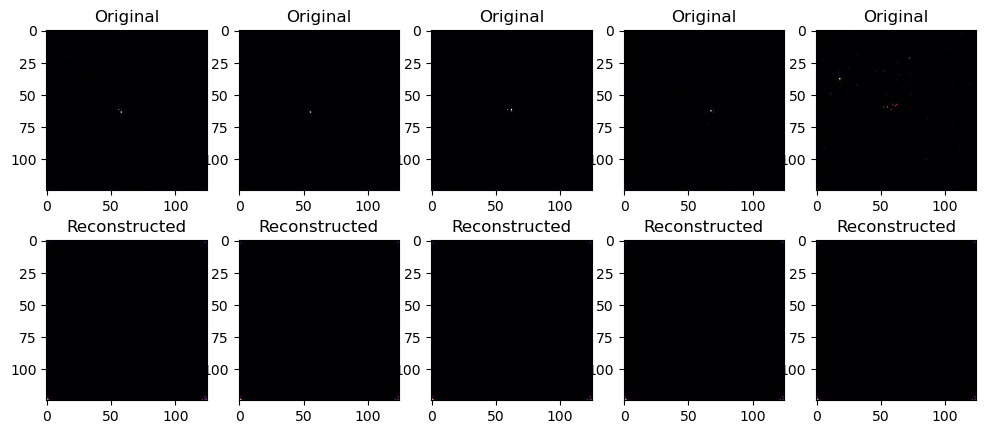

In [16]:
import matplotlib.pyplot as plt

images,_ = next(iter(test_loader))
images = images.to(device)

recon = model(images)
recon = recon[:, :, :125, :125]

fig, ax = plt.subplots(2,5, figsize=(12,5))

for i in range(5):

    original = torch.log1p(images[i][0].cpu())
    reconstructed = torch.log1p(recon[i][0].detach().cpu())

    ax[0,i].imshow(original.numpy(), cmap="inferno")
    ax[0,i].set_title("Original")

    ax[1,i].imshow(reconstructed.numpy(), cmap="inferno")
    ax[1,i].set_title("Reconstructed")

plt.show()